# Ripple Testinng

In [1]:


# Loading/Import related packages
import sys
import os

#Usual suspects
import pandas as pd
import numpy as np
import json
import pickle as pkl
import matplotlib.pyplot as plt

#Extras for plotting
from matplotlib.patches import Patch

#Extra for typing
from collections import defaultdict

os.chdir(r"C:\Users\annas\SynologyDrive\MedUniWien\Projects\NeuroClasp\Students\Liz Kalenteridis\Ripple")
# # Needed to point the importer to the src folder
# sys.path.insert(0,r"C:\Users\annas\SynologyDrive\MedUniWien\Projects\NeuroClasp\Students\Liz Kalenteridis\Ripple")

In [2]:
from src.muniverse.algorithms.core import bandpass_signals, notch_signals
from ripple_analysis_functions import get_task_data, remove_spikes, remove_spikes_dict, calc_PSD, emg_inspect, generate_psd_fig, plot_emg_with_psd


In [3]:
# This task used 3 tasks, each with 8 repitions
n_reps = 8
n_tasks = 3
movement_names = ['fist', 'fast_tripod', 'fast_finger_ext']

samp_freq = 2000
n_channels = 32

In [4]:
REPO_DIR  = os.path.abspath(os.getcwd())
INPUT_DIR = os.path.join(REPO_DIR, 'data')
OUTPUT_DIR = os.path.join(REPO_DIR, 'results')

combined_data_1_path = os.path.join(INPUT_DIR, 'emg_recording_giuan_tewst_20260826_122524.pkl')
s1_folder = os.path.join(INPUT_DIR, 'emg_recording_giuan_tewst_20260826_122524_divided')
s2_folder = os.path.join(INPUT_DIR, 'emg_recording_giuan_tewst2_20260826_135844_divided')

result_pandas = pd.read_pickle(combined_data_1_path)
print(result_pandas.keys())
print(result_pandas['trial_metadata']['items'])
# print(result_pandas.items())


dict_keys(['data', 'srate', 'n_channels', 'filtered', 'pre_trigger_seconds', 'timestamp', 'stream_type', 'trial_metadata', 'session_timeline'])
[{'index': 0, 'model': 'fist.glb', 'animation': 0, 'repetitions': 8}, {'index': 1, 'model': 'fasttripodpinch.glb', 'animation': 0, 'repetitions': 8}, {'index': 2, 'model': 'fastfingerext.glb', 'animation': 0, 'repetitions': 8}]


### Signal

In [5]:
s1_full = get_task_data(s1_folder, 8, movement_names, 'move', samp_freq, win = None)
s1_iso4 = get_task_data(s1_folder, 8, movement_names, 'move', samp_freq, win = 4)

s1_fist = s1_full['fist']['combined_emg_reps']
s1_ft = s1_full['fast_tripod']['combined_emg_reps']
s1_ffe = s1_full['fast_finger_ext']['combined_emg_reps']

s1_fist_iso4 = s1_iso4['fist']['combined_emg_reps']
s1_ft_iso4 = s1_iso4['fast_tripod']['combined_emg_reps']
s1_ffe_iso4 = s1_iso4['fast_finger_ext']['combined_emg_reps']

In [6]:
s2_full = get_task_data(s2_folder, 8, movement_names, 'move', samp_freq, win = None)
s2_fist = s2_full['fist']['combined_emg_reps']
s2_ft = s2_full['fast_tripod']['combined_emg_reps']
s2_ffe = s2_full['fast_finger_ext']['combined_emg_reps']


### Noise

In [7]:
s1_rest = get_task_data(s1_folder, 8, ['rest'], 'rest', samp_freq, win = None) # pass the movement_names as only 'rest' to get all rest data
s1_rest_emg = s1_rest['rest']['combined_emg_reps']

In [8]:
s2_rest = get_task_data(s2_folder, 8, ['rest'], 'rest', samp_freq, win = None) # pass the movement_names as only 'rest' to get all rest data
s2_rest_emg = s2_rest['rest']['combined_emg_reps']

### Preprocessing

In [9]:
s1_clean = remove_spikes_dict(s1_full, threshold_std=3)
s1_rest_clean = remove_spikes_dict(s1_rest, threshold_std=3)

s2_clean = remove_spikes_dict(s2_full, threshold_std=3)
s2_rest_clean = remove_spikes_dict(s2_rest, threshold_std=3)

In [10]:
s1_inspect = emg_inspect(s1_full, s1_rest, samp_freq)
s1_clean_inspect = emg_inspect(s1_clean, s1_rest_clean, samp_freq, emg_name_key='combined_emg_reps_clean')


In [11]:
all_psds_noise = []

for rep in s1_rest['rest']['emg_reps']:
    Pn, fn = calc_PSD(
        rep.to_numpy(),
        fsamp=samp_freq,
        nperseg=samp_freq,
        noverlap=samp_freq // 2
    )
    all_psds_noise.append(Pn)

P_mean = np.mean(all_psds_noise, axis=0)

all_psds_sig = []

for rep in s1_full['fist']['emg_reps']:
    Ps, fs = calc_PSD(
        rep.to_numpy(),
        fsamp=samp_freq,
        nperseg=samp_freq,
        noverlap=samp_freq // 2
    )
    all_psds_sig.append(Ps)

In [12]:
# s1_fist_r1 = s1_full['fist']['emg_reps'][0].to_numpy() # fist rep 1
# s1_rest_r1 = s1_rest['rest']['emg_reps'][0].to_numpy() # rest rep 1

# s1_f1_ps, s1_f1_fs = calc_PSD(s1_fist_r1, fsamp=samp_freq, nperseg=samp_freq, noverlap=samp_freq/2)
# s1_r1_pn, s1_r1_fn = calc_PSD(s1_rest_r1, fsamp=samp_freq, nperseg=samp_freq, noverlap=samp_freq/2)

# # Calculate the SNR
# p_s1_fist_r1= np.mean(s1_fist_r1**2)
# p_s1_rest_r1 = np.mean(s1_rest_r1**2)
# snr = 10 * np.log10(p_s1_fist_r1 / p_s1_rest_r1)

# P_mean = np.mean(s1_r1_pn, axis=0)
# P_tot = np.sum(P_mean)

# generate_psd_fig(
#     emg_data=s1_fist_r1,
#     fn = s1_fist_clean_fn,
#     fs = s1_fist_clean_fs,
#     pn = s1_fist_clean_pn,
#     ps = s1_fist_clean_ps,
#     samp_freq=samp_freq,
#     save_path="results/s1_fist_clean_psd.png"
# )

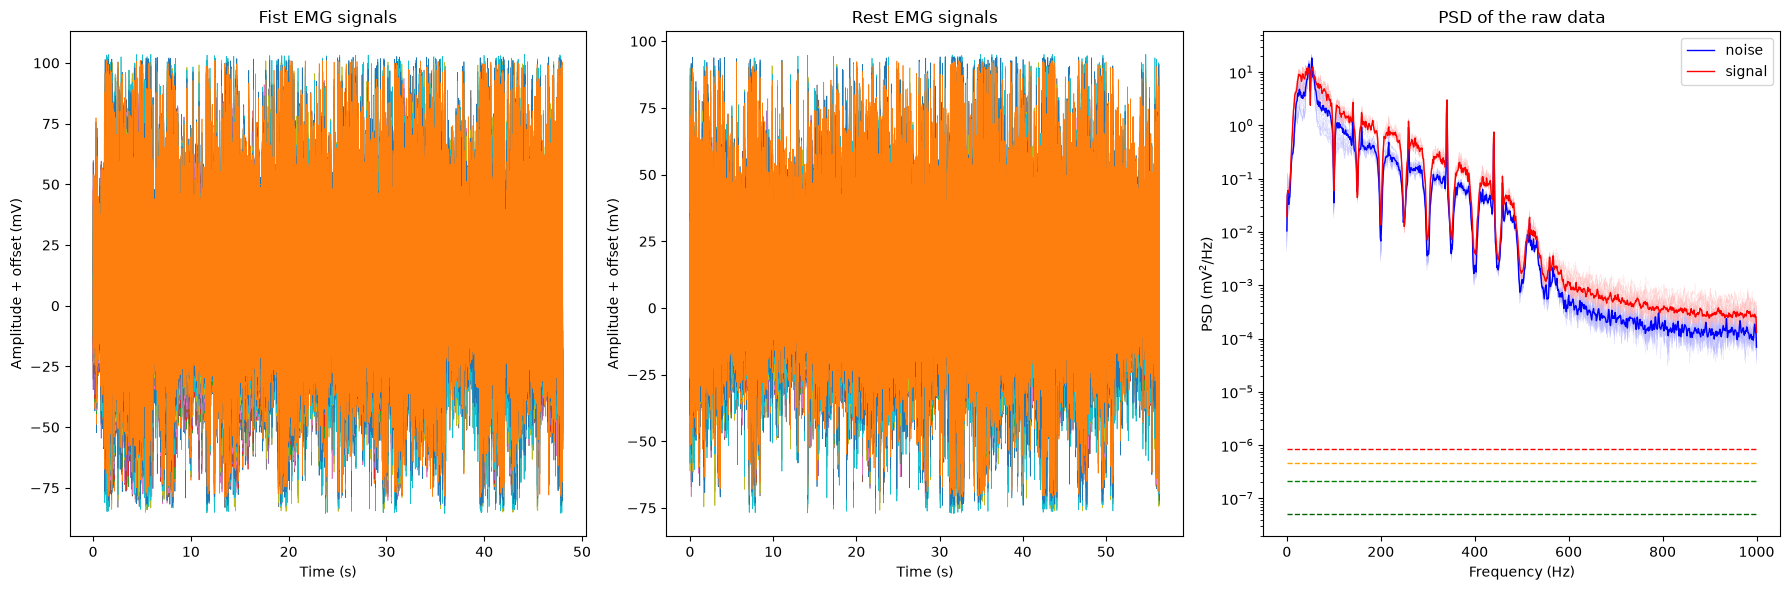

(<Figure size 1800x600 with 3 Axes>,
 array([<Axes: title={'center': 'Fist EMG signals'}, xlabel='Time (s)', ylabel='Amplitude + offset (mV)'>,
        <Axes: title={'center': 'Rest EMG signals'}, xlabel='Time (s)', ylabel='Amplitude + offset (mV)'>,
        <Axes: title={'center': 'PSD of the raw data'}, xlabel='Frequency (Hz)', ylabel='PSD (mV$^2$/Hz)'>],
       dtype=object))

In [13]:
s1_fist_clean = s1_clean['fist']['combined_emg_reps_clean']
s1_rest_clean = s1_rest_clean['rest']['combined_emg_reps_clean']

# generate_psd_fig(
#     emg_data=s1_fist_clean,
#     fn = s1_clean_inspect['rest']['psd'][1],
#     fs = s1_clean_inspect['fist']['psd'][1],
#     pn = s1_clean_inspect['rest']['psd'][0],
#     ps = s1_clean_inspect['fist']['psd'][0],
#     samp_freq=samp_freq,
#     save_path="results/s1_fist_clean_psd.png"
# )

plot_emg_with_psd(
    sig=s1_fist_clean,
    noise=s1_rest_clean,
    fn = s1_clean_inspect['rest']['psd'][1],
    fs = s1_clean_inspect['fist']['psd'][1],
    pn = s1_clean_inspect['rest']['psd'][0],
    ps = s1_clean_inspect['fist']['psd'][0],
    fsamp=samp_freq,
    save_path="results/s1_fist_cleaned_psd.png"
)

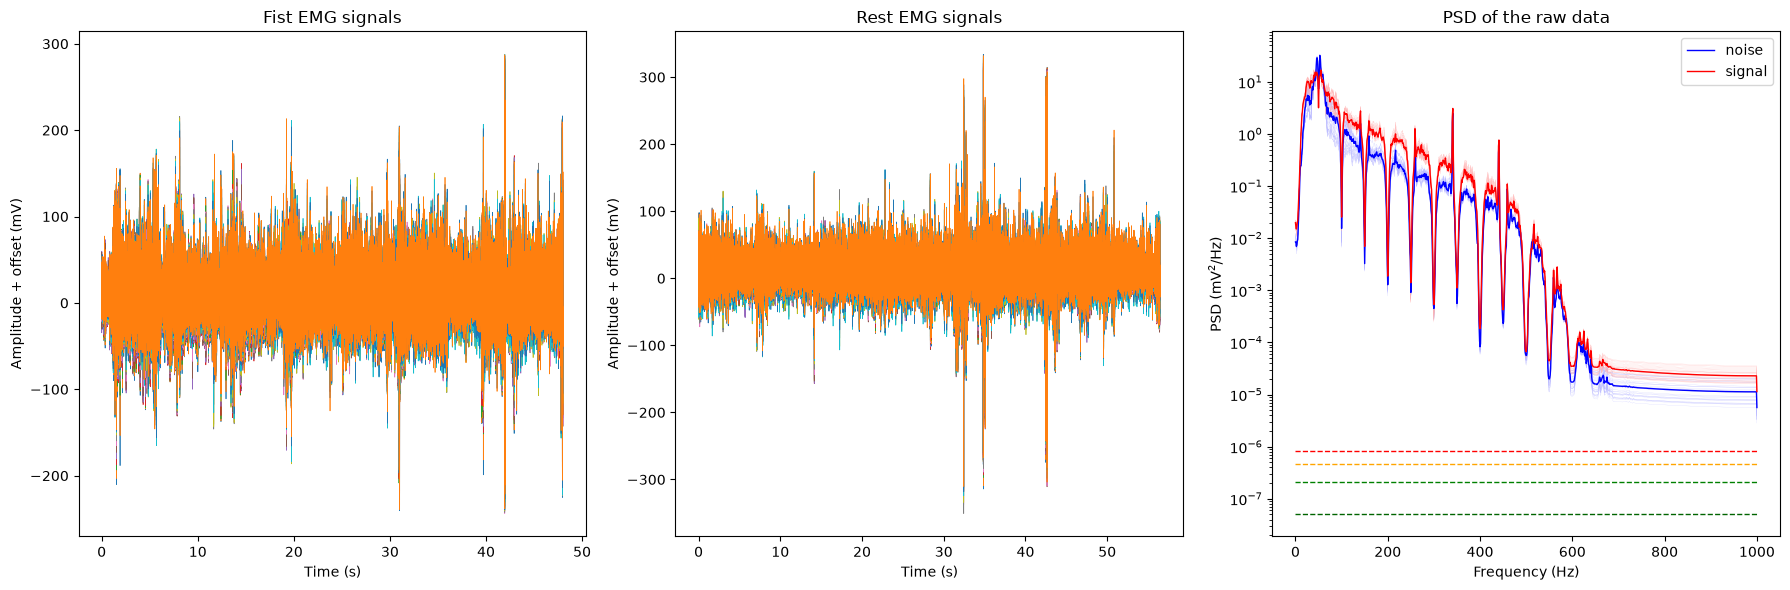

(<Figure size 1800x600 with 3 Axes>,
 array([<Axes: title={'center': 'Fist EMG signals'}, xlabel='Time (s)', ylabel='Amplitude + offset (mV)'>,
        <Axes: title={'center': 'Rest EMG signals'}, xlabel='Time (s)', ylabel='Amplitude + offset (mV)'>,
        <Axes: title={'center': 'PSD of the raw data'}, xlabel='Frequency (Hz)', ylabel='PSD (mV$^2$/Hz)'>],
       dtype=object))

In [14]:
s1_fist = s1_full['fist']['combined_emg_reps']
s1_rest = s1_rest['rest']['combined_emg_reps']

# generate_psd_fig(
#     emg_data=s1_fist,
#     fn = s1_fist_fn,
#     fs = s1_fist_fs,
#     pn = s1_fist_pn,
#     ps = s1_fist_ps,
#     samp_freq=samp_freq,
#     save_path="results/s1_fist_psd.png"
# )
plot_emg_with_psd(
    sig=s1_fist,
    noise=s1_rest,
    fn = s1_inspect['rest']['psd'][1],
    fs = s1_inspect['fist']['psd'][1],
    pn = s1_inspect['rest']['psd'][0],
    ps = s1_inspect['fist']['psd'][0],
    fsamp=samp_freq,
    save_path="results/s1_fist_psd.png"
)

#### Digital Filters

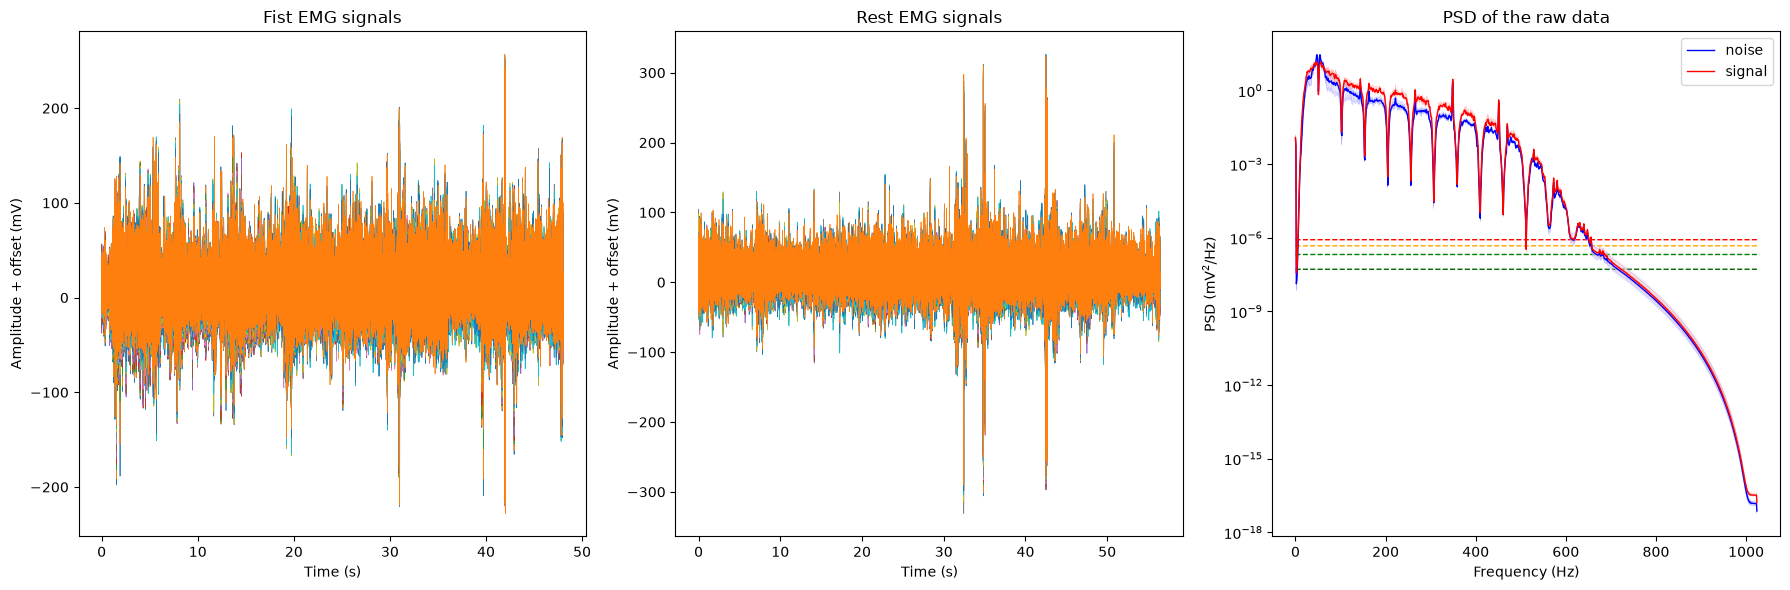

(<Figure size 1800x600 with 3 Axes>,
 array([<Axes: title={'center': 'Fist EMG signals'}, xlabel='Time (s)', ylabel='Amplitude + offset (mV)'>,
        <Axes: title={'center': 'Rest EMG signals'}, xlabel='Time (s)', ylabel='Amplitude + offset (mV)'>,
        <Axes: title={'center': 'PSD of the raw data'}, xlabel='Frequency (Hz)', ylabel='PSD (mV$^2$/Hz)'>],
       dtype=object))

In [ ]:
filtered_emg_sig = s1_fist.copy()
# Apply a notch filter
#for harmonic in range(50, 550, 50):  # 50, 100, 150, ... 500
sig = notch_signals(
    emg_data = filtered_emg_sig, 
    fsamp=samp_freq, 
    nfreq=50, 
    #method="butter", 
    dfreq=1,
    order=2,
    n_harmonics = 6
)
# Apply a bandpass filter
sig = bandpass_signals(
    emg_data=sig,
    fsamp=samp_freq,
    high_pass=20,
    low_pass=500,
    #method="butter",
    order=2
)


filtered_emg_noise = s1_rest.copy()
# Apply a notch filter
noise = notch_signals(
    emg_data=filtered_emg_noise,
    fsamp=samp_freq,
    nfreq=50,
    #method="butter",
    dfreq=1,
    order=2,
    n_harmonics = 6
)
# Apply a bandpass filter
# for harmonic in range(50, 550, 50):  # 50, 100, 150, ... 500
noise = bandpass_signals(
    emg_data=noise,
    fsamp=samp_freq,
    high_pass=20,
    low_pass=500,
    #method="butter",
    order=2
)

# Calculate the power spectral density (PSD)
Pn, fn = calc_PSD(noise)
Ps, fs = calc_PSD(sig)

# Calculate the SNR
p_sig = np.mean(sig**2)
p_noise = np.mean(noise**2)
snr = 10 * np.log10(p_sig / p_noise)

plot_emg_with_psd(
    sig=sig,
    noise=noise,
    fn = fn,
    fs = fs,
    pn = Pn,
    ps = Ps,
    fsamp=samp_freq,
    save_path="results/s1_fist_filter_harm6.png"
)
